In [0]:
# Load the merged dataset from workspace.default.merged_data_set
from pyspark.sql import SparkSession
spark = SparkSession.getActiveSession()
df_merged = spark.table('workspace.default.merged_data_set')

# Convert to pandas DataFrame for EDA
pdf_merged = df_merged.toPandas()

# Display basic info
display(df_merged)

USERID,TIMESTAMP,WAP011,WAP012,WAP051,WAP052,WAP059,WAP060,WAP061,WAP062,WAP063,WAP064,WAP065,WAP066,WAP069,WAP070,WAP073,WAP074,WAP077,WAP078,WAP082,WAP083,WAP084,WAP085,WAP087,WAP096,WAP097,WAP098,WAP099,WAP117,WAP118,WAP121,WAP122,WAP127,WAP128,WAP131,WAP132,WAP144,WAP145,WAP155,WAP156,WAP161,WAP162,WAP248,WAP277,WAP332,WAP389,WAP478,WAP489,WAP495,WAP496,WAP501,WAP502,WAP516,WAP517,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,PHONEID,WAP013,WAP014,WAP035,WAP036,WAP041,WAP042,WAP067,WAP068,WAP138,WAP139,WAP203,WAP204,WAP503,path,modificationTime,length,content,filename
2,1371714095,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-78,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-7519.152399998158,4864949.532200001,2,1,103,2,23,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,null,null,null,null,null
2,1371713807,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-7524.5703999996185,4864934.093000002,2,1,102,2,23,-110,-110,-92,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,null,null,null,null,null
2,1371713883,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-81,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-7519.152399998158,4864949.532200001,2,1,103,2,23,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,null,null,null,null,null
2,1371713775,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-7527.451099999249,4864929.146399997,2,1,101,2,23,-110,-110,-110,-96,-110,-110,-110,-110,-110,-110,-110,-110,-110,null,null,null,null,null
2,1371714128,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-69,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-7510.437173217535,4864949.251416706,2,1,103,1,23,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,null,null,null,null,null
2,1371714200,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-97,-94,-110,-110,-80,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-7528.816401548684,4864959.430612221,2,1,104,1,23,-110,-110,-110,-94,-110,-110,-110,-110,-110,-110,-110,-110,-110,null,null,null,null,null
2,1371714730,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-94,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-7520.724500000477,4864892.4384,2,1,15,2,23,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,null,null,null,null,null
2,1371715041,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-86,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-7489.177499998361,4864899.944899999,2,1,10,2,23,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,null,null,null,null,null
2,1371716152,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-110,-

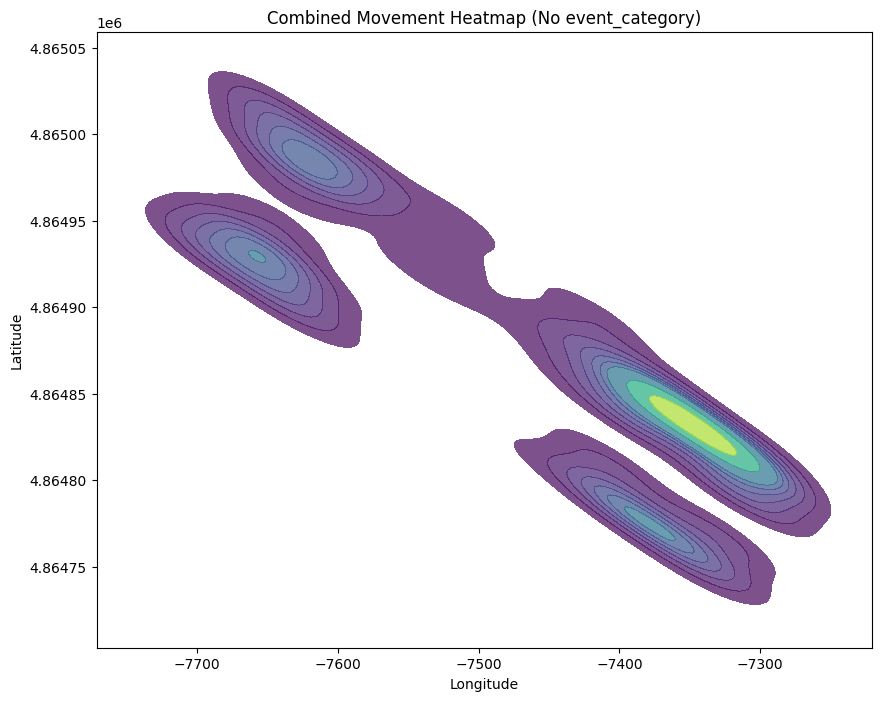

In [0]:
# Combined Movement + Logs Heatmap
# Visualize LATITUDE, LONGITUDE, and event_category (if available)
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load merged dataset if not already loaded
df_merged = spark.table('workspace.default.merged_data_set')
pdf_merged = df_merged.toPandas()

folder = 'EDA_Outputs/Combined_Movement_Heatmap'
os.makedirs(folder, exist_ok=True)

# Check if 'event_category' exists, otherwise use a placeholder
if 'event_category' in pdf_merged.columns:
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=pdf_merged, x='LONGITUDE', y='LATITUDE', hue='event_category', alpha=0.5)
    plt.title('Combined Movement + Logs Heatmap')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend(title='Event Category')
    plt.show()
    plt.savefig(f'{folder}/plot.png')
else:
    plt.figure(figsize=(10, 8))
    sns.kdeplot(data=pdf_merged, x='LONGITUDE', y='LATITUDE', fill=True, cmap='viridis', alpha=0.7)
    plt.title('Combined Movement Heatmap (No event_category)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()
    plt.savefig(f'{folder}/plot.png')

with open(f'{folder}/readme.md', 'w') as f:
    f.write("""# Combined Movement + Logs Heatmap

This visualization shows the movement data from the mall, plotting latitude and longitude.

If event_category is available, it uses a scatter plot colored by event category.

Otherwise, it shows a density heatmap.

""")

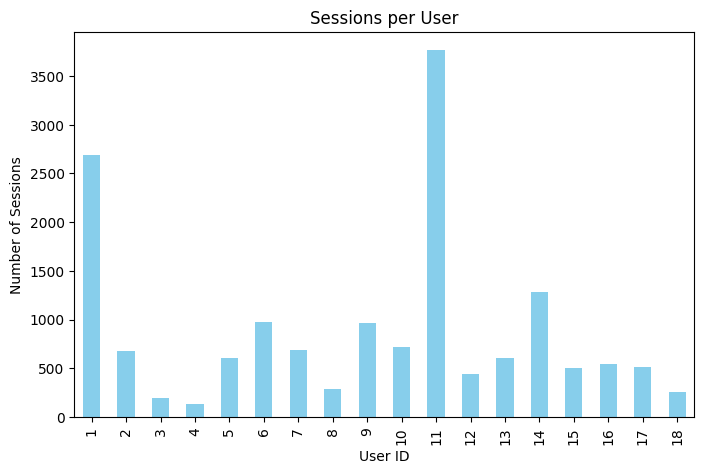

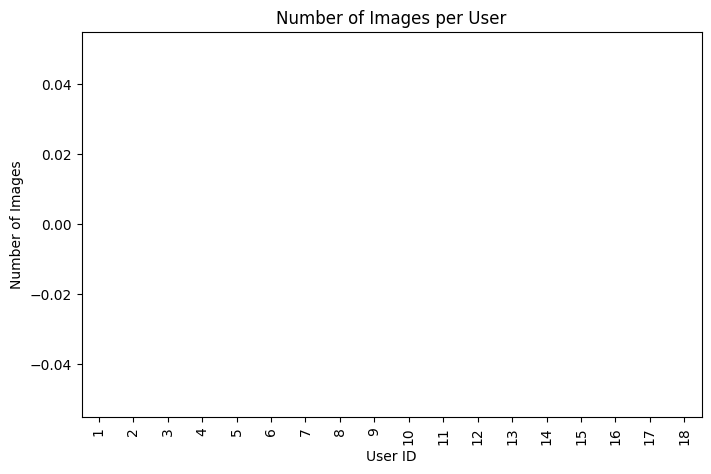

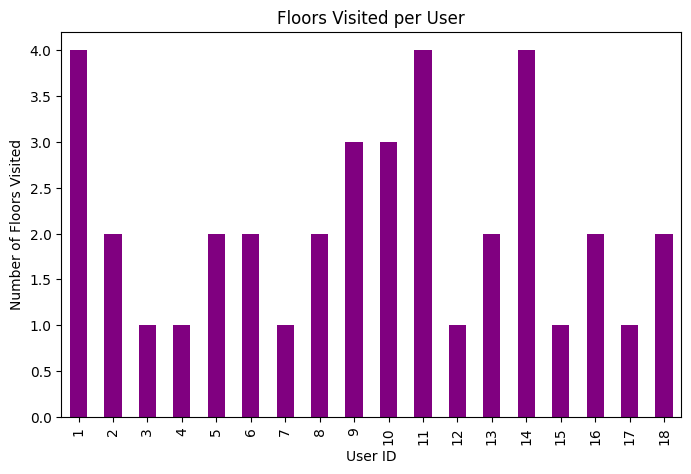

In [0]:
# User-Level Summary: Sessions, Images, Events, Floors Visited
import numpy as np
import os

folder = 'EDA_Outputs/User_Level_Summary'
os.makedirs(folder, exist_ok=True)

# Sessions per user
sessions_per_user = pdf_merged.groupby('USERID').size()
plt.figure(figsize=(8, 5))
sessions_per_user.plot(kind='bar', color='skyblue')
plt.title('Sessions per User')
plt.xlabel('User ID')
plt.ylabel('Number of Sessions')
plt.show()
plt.savefig(f'{folder}/sessions.png')

# Number of images per user (if 'filename' or 'images' column exists)
if 'filename' in pdf_merged.columns:
    images_per_user = pdf_merged.groupby('USERID')['filename'].count()
    plt.figure(figsize=(8, 5))
    images_per_user.plot(kind='bar', color='orange')
    plt.title('Number of Images per User')
    plt.xlabel('User ID')
    plt.ylabel('Number of Images')
    plt.show()
    plt.savefig(f'{folder}/images.png')

# Number of events per user (if 'event_category' exists)
if 'event_category' in pdf_merged.columns:
    events_per_user = pdf_merged.groupby('USERID')['event_category'].count()
    plt.figure(figsize=(8, 5))
    events_per_user.plot(kind='bar', color='green')
    plt.title('Number of Events per User')
    plt.xlabel('User ID')
    plt.ylabel('Number of Events')
    plt.show()
    plt.savefig(f'{folder}/events.png')

# Floors visited per user
floors_per_user = pdf_merged.groupby('USERID')['FLOOR'].nunique()
plt.figure(figsize=(8, 5))
floors_per_user.plot(kind='bar', color='purple')
plt.title('Floors Visited per User')
plt.xlabel('User ID')
plt.ylabel('Number of Floors Visited')
plt.show()
plt.savefig(f'{folder}/floors.png')

with open(f'{folder}/readme.md', 'w') as f:
    f.write("""# User-Level Summary

This section provides summaries per user:

- Sessions per user: Bar chart showing the number of sessions for each user.

- Number of images per user: Bar chart of images uploaded or associated per user (if filename column exists).

- Number of events per user: Bar chart of events per user (if event_category exists).

- Floors visited per user: Bar chart showing the number of unique floors visited by each user.

""")

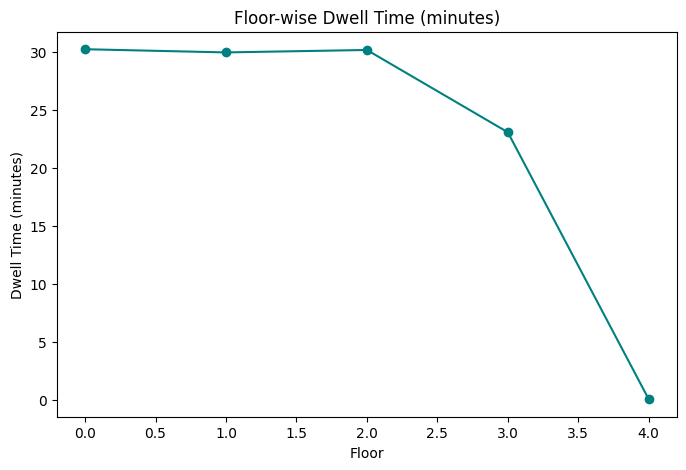

In [0]:
# Floor-wise Dwell Time (Line Chart)
# Calculate time spent per floor (assuming TIMESTAMP is in milliseconds)
import pandas as pd
import os

folder = 'EDA_Outputs/Floor_wise_Dwell_Time'
os.makedirs(folder, exist_ok=True)

pdf_merged['TIMESTAMP'] = pd.to_datetime(pdf_merged['TIMESTAMP'], unit='ms')
dwell_time = pdf_merged.groupby('FLOOR')['TIMESTAMP'].apply(lambda x: (x.max() - x.min()).total_seconds()/60)
plt.figure(figsize=(8, 5))
dwell_time.plot(kind='line', marker='o', color='teal')
plt.title('Floor-wise Dwell Time (minutes)')
plt.xlabel('Floor')
plt.ylabel('Dwell Time (minutes)')
plt.show()
plt.savefig(f'{folder}/plot.png')

with open(f'{folder}/readme.md', 'w') as f:
    f.write("""# Floor-wise Dwell Time

This line chart shows the total dwell time (in minutes) per floor in the mall.

Dwell time is calculated as the difference between the maximum and minimum timestamp for each floor.

""")

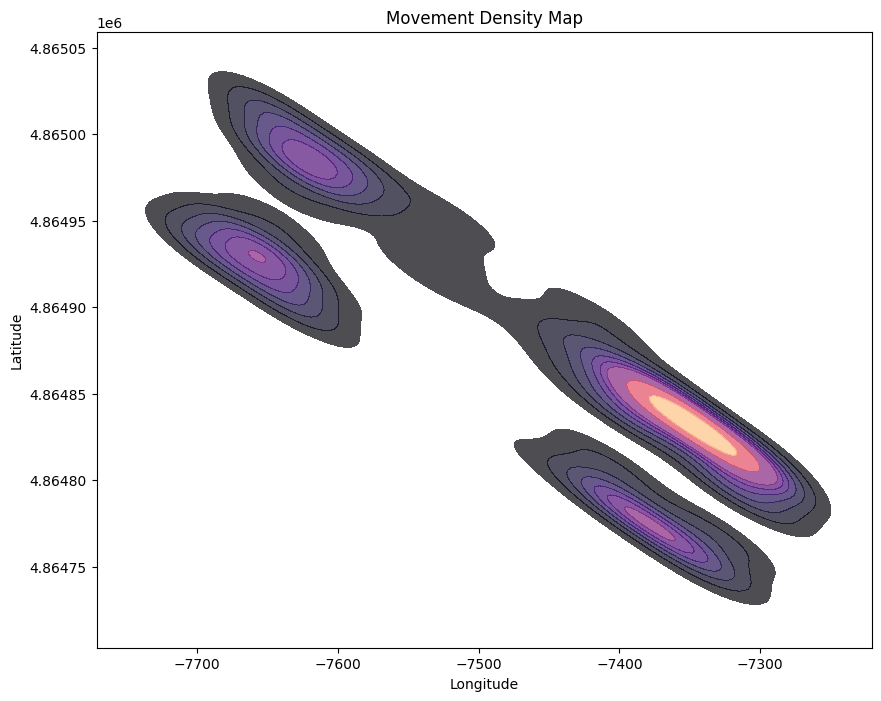

In [0]:
# Movement Density Map (Heatmap)
import os

folder = 'EDA_Outputs/Movement_Density_Map'
os.makedirs(folder, exist_ok=True)

plt.figure(figsize=(10, 8))
sns.kdeplot(data=pdf_merged, x='LONGITUDE', y='LATITUDE', fill=True, cmap='magma', alpha=0.7)
plt.title('Movement Density Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()
plt.savefig(f'{folder}/plot.png')

with open(f'{folder}/readme.md', 'w') as f:
    f.write("""# Movement Density Map

This heatmap shows the density of movement in the mall based on latitude and longitude data.

It uses a kernel density estimate to visualize areas with higher activity.

""")

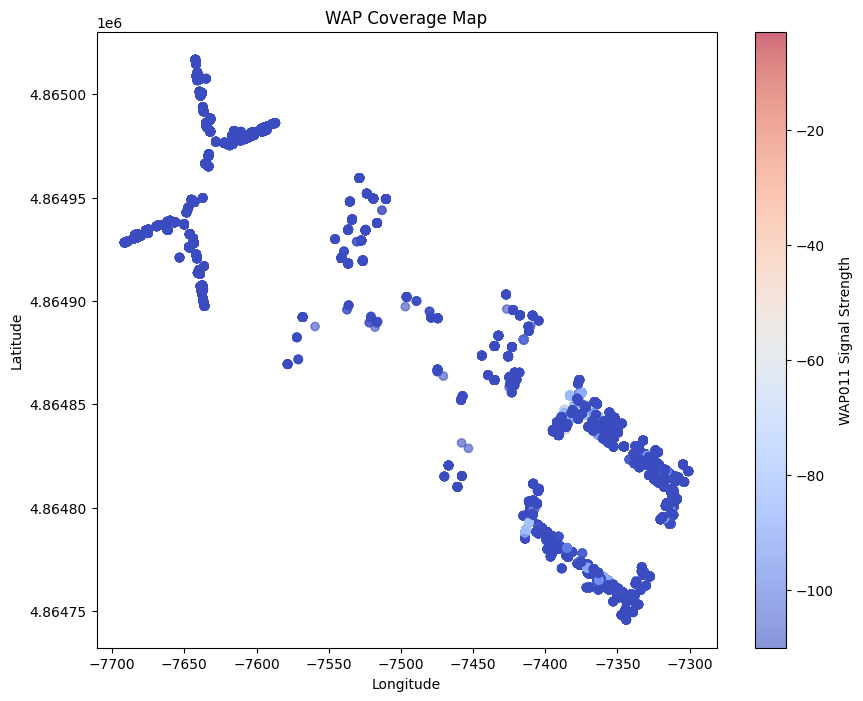

In [0]:
# WAP Coverage Map (Scatter + Color Scale)
# Use a sample WAP column for signal strength visualization
import os

folder = 'EDA_Outputs/WAP_Coverage_Map'
os.makedirs(folder, exist_ok=True)

wap_cols = [col for col in pdf_merged.columns if col.startswith('WAP')]
if wap_cols:
    wap_col = wap_cols[0]  # Use the first WAP column
    plt.figure(figsize=(10, 8))
    sc = plt.scatter(pdf_merged['LONGITUDE'], pdf_merged['LATITUDE'], c=pdf_merged[wap_col], cmap='coolwarm', alpha=0.6)
    plt.colorbar(sc, label=f'{wap_col} Signal Strength')
    plt.title('WAP Coverage Map')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()
    plt.savefig(f'{folder}/plot.png')

with open(f'{folder}/readme.md', 'w') as f:
    f.write("""# WAP Coverage Map

This scatter plot shows the WAP (Wireless Access Point) signal strength across the mall.

Points are colored by the signal strength of the first WAP column found in the data.

""")